# When the City Closed Its Doors: Animal Outcomes Before, During, and After COVID

This notebook analyzes **Austin Animal Center outcome data** with a story-driven structure.

The central question is:

> **Did the COVID-19 pandemic change what happened to cats and dogs in the shelter system?**

Instead of only showing tables, this notebook follows the animals through three historical periods:

1. **Before COVID**: 2018–2019  
2. **During COVID**: 2020–2021  
3. **After COVID**: 2022–2024  

The emotional storyline is simple: during COVID, humans changed their daily lives dramatically. Shelters, adoption systems, partner networks, and families were also affected. Behind every row in the dataset is an animal whose outcome may have depended on this changed world.

## 1. Import Libraries

We use:

- **pandas** for data cleaning and analysis
- **matplotlib / seaborn** for visualization
- **scipy** for statistical testing

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal

# Make plots easier to read
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset


In [3]:
csv_path = Path("Austin_Animal_Center_Outcomes_10_01_2013_to_05_05_2025_20260422.csv")

df = pd.read_csv(csv_path, low_memory=False)

print("Original shape:", df.shape)
df.head()

Original shape: (173775, 12)


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,12/1/2012,NaN,2013-12-02T00:00:00-05:00,13-Dec,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2/22/2012,NaN,2014-02-22T00:00:00-05:00,14-Feb,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,4/3/2013,NaN,2014-04-07T00:00:00-05:00,14-Apr,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,4/16/2014,NaN,2014-05-16T00:00:00-05:00,14-May,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,5/25/2014,NaN,2014-06-10T00:00:00-05:00,14-Jun,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


## 3. Keep Only the Columns Needed for the Story

For this project, we focus on a simple but meaningful set of variables:

- **Name**: whether the animal had a known name
- **MonthYear**: when the outcome happened
- **Outcome Type**: what happened to the animal
- **Animal Type**: cat or dog
- **Age upon Outcome**: age at the moment of outcome

Other columns may be useful in another project, but removing them helps keep the exam analysis focused.

In [4]:
columns_to_drop = [
    "Animal ID", "Date of Birth", "DateTime", "Outcome Subtype",
    "Sex upon Outcome", "Breed", "Color"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Shape after selecting story columns:", df.shape)
df.head()

Shape after selecting story columns: (173775, 5)


,Name,MonthYear,Outcome Type,Animal Type,Age upon Outcome
0,NaN,13-Dec,Transfer,Other,1 year
1,NaN,14-Feb,Euthanasia,Other,2 years
2,NaN,14-Apr,Transfer,Other,1 year
3,NaN,14-May,NaN,Other,4 weeks
4,NaN,14-Jun,Transfer,Bird,2 weeks


## 4. Filter the Study Period: 2018–2024

The column `MonthYear` has a format such as:

- `18-Jan` = January 2018
- `24-Dec` = December 2024

We extract the first two characters and use them as the year code.

In [5]:
def filter_year_range(df, column="MonthYear", start=18, end=24):
    """Keep rows where the YY part of MonthYear is between start and end."""
    year_code = pd.to_numeric(df[column].str[:2], errors="coerce")
    return df[year_code.between(start, end)].copy()


df = filter_year_range(df, column="MonthYear", start=18, end=24)
print("Shape after filtering 2018–2024:", df.shape)
df.head()

Shape after filtering 2018–2024: (93119, 5)


,Name,MonthYear,Outcome Type,Animal Type,Age upon Outcome
1918,*Dean,18-Jan,Transfer,Dog,1 year
1919,Ivan,18-Jan,Transfer,Cat,12 years
1920,*Dasher,18-Jan,Transfer,Dog,1 year
1921,Jade,18-Jan,Transfer,Dog,2 years
1922,Manchas,18-Jan,Transfer,Dog,1 year


## 5. Focus on Cats and Dogs

Cats and dogs are the most common companion animals.  
Focusing on them makes the comparison more consistent and emotionally clear: These are the animals most likely to be adopted, returned, transferred, or affected by changes in human behavior during COVID.

In [6]:
def filter_animal_types(df, types, column="Animal Type"):
    """Keep only selected animal types."""
    return df[df[column].isin(types)].copy()


df = filter_animal_types(df, ["Cat", "Dog"])
print("Shape after keeping only cats and dogs:", df.shape)
df.head()

Shape after keeping only cats and dogs: (87983, 5)


,Name,MonthYear,Outcome Type,Animal Type,Age upon Outcome
1918,*Dean,18-Jan,Transfer,Dog,1 year
1919,Ivan,18-Jan,Transfer,Cat,12 years
1920,*Dasher,18-Jan,Transfer,Dog,1 year
1921,Jade,18-Jan,Transfer,Dog,2 years
1922,Manchas,18-Jan,Transfer,Dog,1 year


## 6. Drop Rows with Missing Values Except `Name`

The `Name` column is allowed to be empty because many shelter animals arrive unnamed.  
However, the analysis requires the other columns to be complete.

Therefore, rows are removed only if they have missing values in important analytical columns.

In [7]:
def drop_rows_with_missing_except_name(df):
    """Drop rows with missing values in all columns except Name."""
    df_copy = df.copy()
    df_copy = df_copy.replace("", pd.NA)
    cols_to_check = [col for col in df_copy.columns if col != "Name"]
    return df_copy.dropna(subset=cols_to_check).copy()


before_rows = len(df)
df = drop_rows_with_missing_except_name(df)
after_rows = len(df)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)
df.head()

Rows before cleaning: 87983
Rows after cleaning: 87949
Rows removed: 34


,Name,MonthYear,Outcome Type,Animal Type,Age upon Outcome
1918,*Dean,18-Jan,Transfer,Dog,1 year
1919,Ivan,18-Jan,Transfer,Cat,12 years
1920,*Dasher,18-Jan,Transfer,Dog,1 year
1921,Jade,18-Jan,Transfer,Dog,2 years
1922,Manchas,18-Jan,Transfer,Dog,1 year


## 7. Create Year and Pandemic Period Columns

We divide the data into three periods:

| Period | Years | Meaning |
|---|---:|---|
| Before | 2018–2019 | Normal shelter operation before COVID |
| During | 2020–2021 | Main pandemic disruption period |
| After | 2022–2024 | Recovery and post-pandemic period |

This allows us to compare whether animal outcomes changed across social conditions.

In [8]:
df.to_csv("cleaned_dataset.csv", index=False)
import os
os.getcwd()

'c:\\Users\\01it.ir\\Desktop\\animal_project'

In [9]:
def label_period(year):
    if 18 <= year <= 19:
        return "Before COVID"
    elif 20 <= year <= 21:
        return "During COVID"
    elif 22 <= year <= 24:
        return "After COVID"
    else:
        return "Other"


df["Year"] = pd.to_numeric(df["MonthYear"].str[:2], errors="coerce").astype("Int64")
df["Period"] = df["Year"].apply(label_period)

# Convert two-digit year to full year for plotting
# Example: 18 -> 2018
df["Full Year"] = 2000 + df["Year"].astype(int)

period_order = ["Before COVID", "During COVID", "After COVID"]
df["Period"] = pd.Categorical(df["Period"], categories=period_order, ordered=True)

df[["MonthYear", "Year", "Full Year", "Period"]].head()

,MonthYear,Year,Full Year,Period
1918,18-Jan,18,2018,Before COVID
1919,18-Jan,18,2018,Before COVID
1920,18-Jan,18,2018,Before COVID
1921,18-Jan,18,2018,Before COVID
1922,18-Jan,18,2018,Before COVID


## 8. Convert Age Text into Numeric Days

The original age column contains text values such as:

- `2 weeks`
- `5 months`
- `1 year`
- `3 years`

For statistical analysis, text must be converted into numbers.  
Here, every age is converted into **days**.

In [10]:
def convert_age_to_days(age):
    """Convert age strings like '2 weeks' or '1 year' into approximate days."""
    try:
        value, unit = str(age).split()[:2]
        value = int(value)
        unit = unit.lower()

        if "day" in unit:
            return value
        elif "week" in unit:
            return value * 7
        elif "month" in unit:
            return value * 30
        elif "year" in unit:
            return value * 365
        else:
            return pd.NA
    except Exception:
        return pd.NA


df["Age days"] = df["Age upon Outcome"].apply(convert_age_to_days)
df["Age years"] = pd.to_numeric(df["Age days"], errors="coerce") / 365

# Remove rows where age could not be converted
df = df.dropna(subset=["Age days"]).copy()

print("Shape after age conversion:", df.shape)
df[["Age upon Outcome", "Age days", "Age years"]].head()

Shape after age conversion: (87949, 10)


,Age upon Outcome,Age days,Age years
1918,1 year,365,1.0
1919,12 years,4380,12.0
1920,1 year,365,1.0
1921,2 years,730,2.0
1922,1 year,365,1.0


## 9. Create Age Groups

Age groups make the story easier to understand:

- **Baby**: younger than 1 month
- **Young**: 1 month to less than 1 year
- **Adult**: 1 year to less than 8 years
- **Senior**: 8 years or older

This helps us ask whether very young or older animals were affected differently.

In [11]:
def age_group(days):
    if days < 30:
        return "Baby"
    elif days < 365:
        return "Young"
    elif days < 365 * 8:
        return "Adult"
    else:
        return "Senior"


df["Age Group"] = df["Age days"].apply(age_group)

df["Age Group"].value_counts()

Age Group
Adult     38909
Young     36651
Baby       6846
Senior     5543
Name: count, dtype: int64

In [12]:
output_path = "animal_covid_cleaned.csv"

df.to_csv(output_path, index=False)

print(f"Exported {len(df):,} rows × {df.shape[1]} columns → {output_path}")
print("\nColumns saved:")
print(df.dtypes.to_string())

Exported 87,949 rows × 11 columns → animal_covid_cleaned.csv

Columns saved:
Name                     str
MonthYear                str
Outcome Type             str
Animal Type              str
Age upon Outcome         str
Year                   Int64
Period              category
Full Year              int64
Age days               int64
Age years            float64
Age Group                str


# Part A — First Look at the Shelter Story

Before testing COVID effects, we first look at the basic structure of the data.

## 10. How Many Animals Are in Each Period?

This plot shows how many cat and dog outcomes were recorded before, during, and after COVID.

A change in count may suggest that shelter operations, public access, adoption behavior, or intake patterns changed during the pandemic.

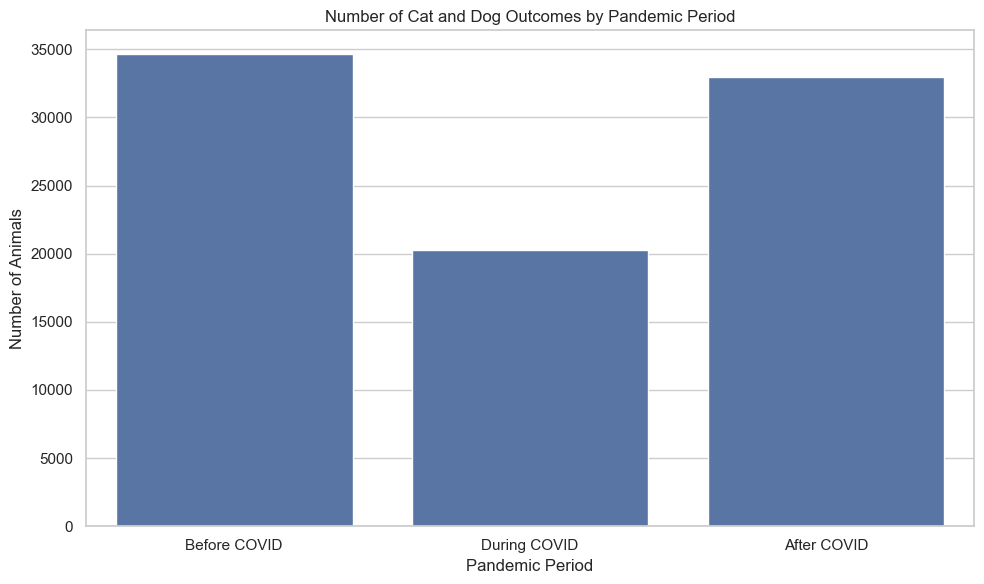

Period
Before COVID    34652
During COVID    20298
After COVID     32999
Name: count, dtype: int64

In [13]:
ax = sns.countplot(data=df, x="Period", order=period_order)
ax.set_title("Number of Cat and Dog Outcomes by Pandemic Period")
ax.set_xlabel("Pandemic Period")
ax.set_ylabel("Number of Animals")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

period_counts = df["Period"].value_counts().reindex(period_order)
period_counts

## 11. Outcome Distribution by Period

This plot answers the main emotional question:

> During COVID, did animals have different outcomes than before or after?

Examples of outcome types may include adoption, transfer, return to owner, euthanasia, or other outcomes.

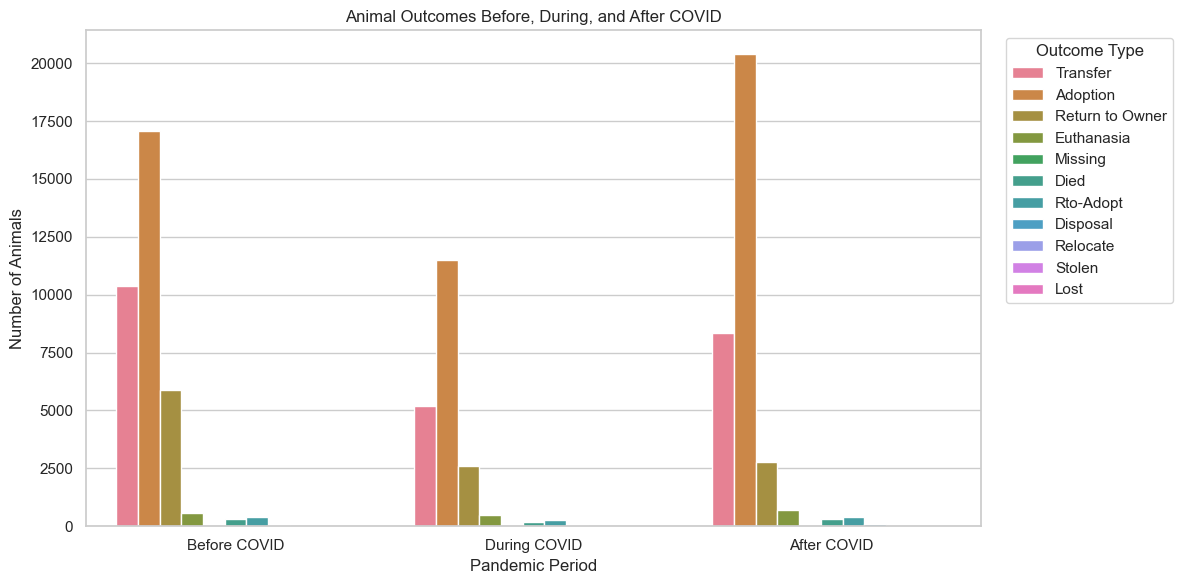

Outcome Type,Adoption,Died,Disposal,Euthanasia,Lost,Missing,Relocate,Return to Owner,Rto-Adopt,Stolen,Transfer
Period,,,,,,,,,,,
Before COVID,17064,323,43,552,0,19,0,5871,417,0,10363
During COVID,11485,196,72,477,0,4,4,2581,271,0,5208
After COVID,20396,314,110,683,1,19,2,2756,387,5,8326


In [14]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="Period", hue="Outcome Type", order=period_order)
ax.set_title("Animal Outcomes Before, During, and After COVID")
ax.set_xlabel("Pandemic Period")
ax.set_ylabel("Number of Animals")
plt.legend(title="Outcome Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pd.crosstab(df["Period"], df["Outcome Type"])

## 12. Outcome Percentages by Period

Raw counts can be misleading because the periods do not necessarily contain the same number of rows.

A percentage plot is often better for comparison because it shows the **share** of each outcome inside each period.

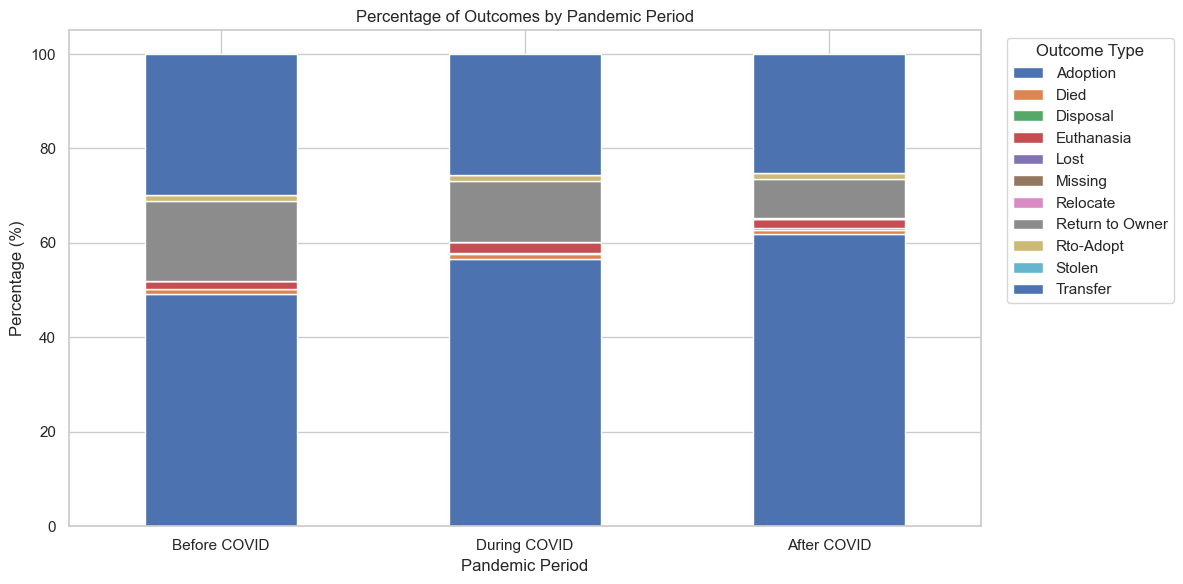

Outcome Type,Adoption,Died,Disposal,Euthanasia,Lost,Missing,Relocate,Return to Owner,Rto-Adopt,Stolen,Transfer
Period,,,,,,,,,,,
Before COVID,49.24,0.93,0.12,1.59,0.0,0.05,0.00,16.94,1.20,0.00,29.91
During COVID,56.58,0.97,0.35,2.35,0.0,0.02,0.02,12.72,1.34,0.00,25.66
After COVID,61.81,0.95,0.33,2.07,0.0,0.06,0.01,8.35,1.17,0.02,25.23


In [15]:
outcome_percent = pd.crosstab(df["Period"], df["Outcome Type"], normalize="index") * 100

ax = outcome_percent.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Percentage of Outcomes by Pandemic Period")
ax.set_xlabel("Pandemic Period")
ax.set_ylabel("Percentage (%)")
plt.legend(title="Outcome Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

outcome_percent.round(2)

# Part C — Cats and Dogs: Did the Two Groups Experience COVID Differently?

Cats and dogs may have different adoption patterns, transfer networks, and owner-return patterns.  
So we compare them separately.

## 13. Animal Type by Period

This plot shows whether the balance between cats and dogs changed across the three periods.

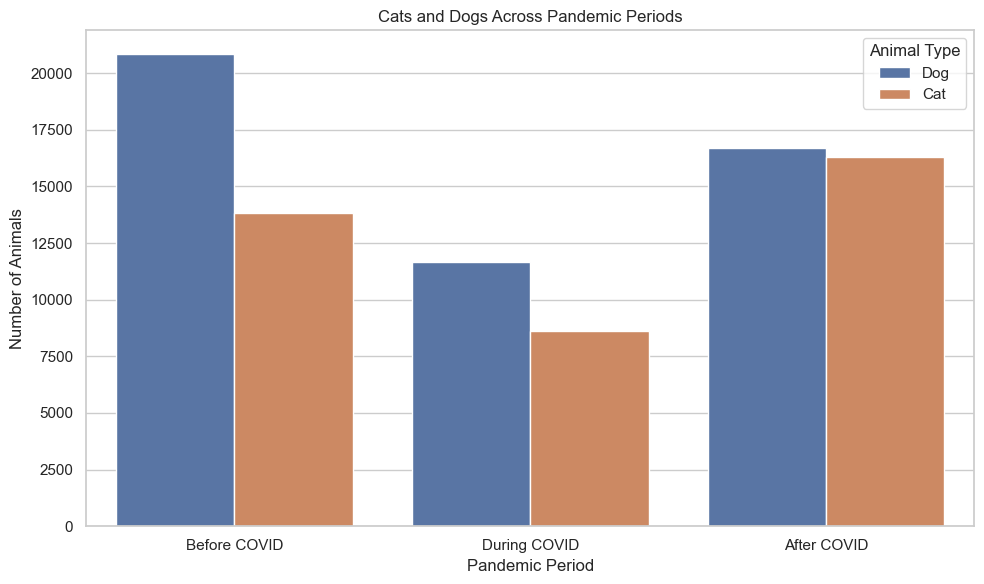

Animal Type,Cat,Dog
Period,,
Before COVID,13808,20844
During COVID,8618,11680
After COVID,16296,16703


In [16]:
ax = sns.countplot(data=df, x="Period", hue="Animal Type", order=period_order)
ax.set_title("Cats and Dogs Across Pandemic Periods")
ax.set_xlabel("Pandemic Period")
ax.set_ylabel("Number of Animals")
plt.legend(title="Animal Type")
plt.tight_layout()
plt.show()

pd.crosstab(df["Period"], df["Animal Type"])

# Part D — Age as a Vulnerability Factor

Age gives the analysis more emotional depth. A baby animal, an adult animal, and a senior animal do not face the shelter system in the same way.

The question becomes: Were animals during COVID younger, older, or different in age compared with before and after?

## 14. Average Age by Period

This table compares the mean age of animals in each period.

In [17]:
age_summary = df.groupby("Period", observed=False)["Age years"].agg(["count", "mean", "median", "min", "max"])
age_summary.round(2)

,count,mean,median,min,max
Period,,,,,
Before COVID,34652,2.05,1.00,-4.0,24.0
During COVID,20298,2.01,1.00,0.0,23.0
After COVID,32999,1.64,0.66,0.0,20.0


## 16. Age Group and Outcome

This plot connects vulnerability and outcome.

It asks:

> Did babies, young animals, adults, and seniors experience different outcomes?

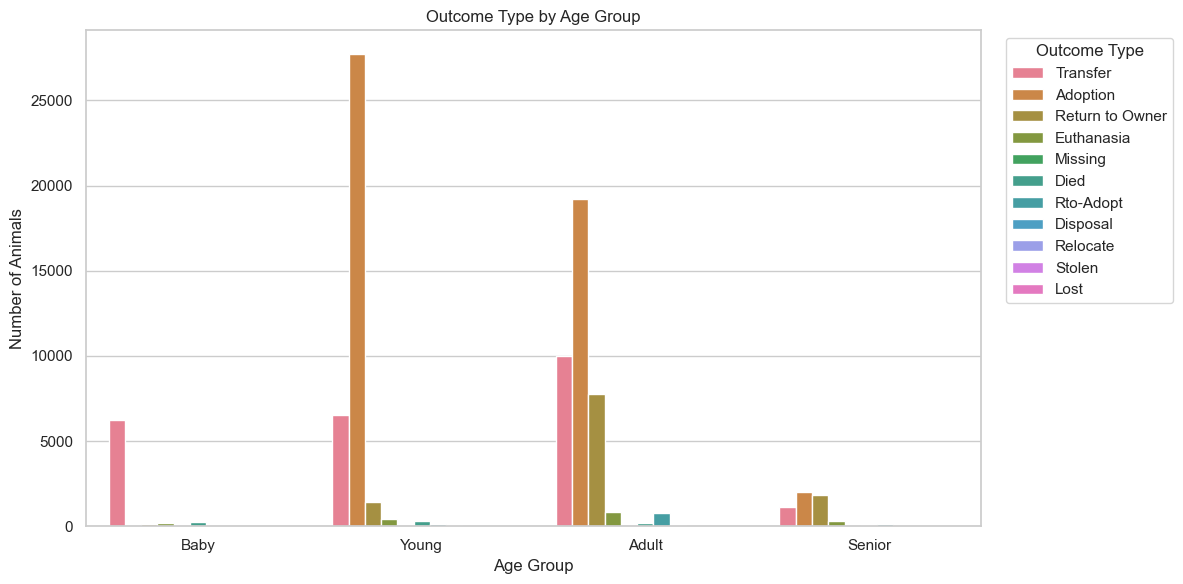

Outcome Type,Adoption,Died,Disposal,Euthanasia,Lost,Missing,Relocate,Return to Owner,Rto-Adopt,Stolen,Transfer
Age Group,,,,,,,,,,,
Baby,20,241,31,167,0,1,0,139,10,0,6237
Young,27718,328,73,411,1,21,1,1423,150,1,6524
Adult,19201,198,98,814,0,20,4,7785,801,3,9985
Senior,2006,66,23,320,0,0,1,1861,114,1,1151


In [18]:
age_order = ["Baby", "Young", "Adult", "Senior"]

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="Age Group", hue="Outcome Type", order=age_order)
ax.set_title("Outcome Type by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Animals")
plt.legend(title="Outcome Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pd.crosstab(df["Age Group"], df["Outcome Type"]).reindex(age_order)

# Part E — Time Trend: The Long View

COVID was not only a category. It was a historical interruption.  
A year-by-year plot helps show the timeline more naturally.

## 17. Number of Outcomes by Year

This line plot shows whether the number of recorded outcomes changed over time.

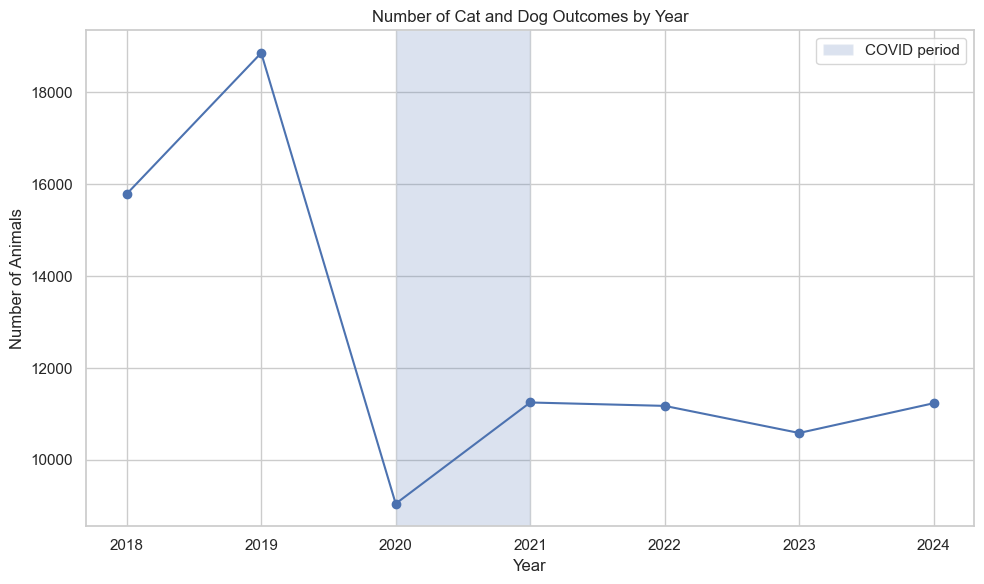

Full Year
2018    15791
2019    18861
2020     9047
2021    11251
2022    11177
2023    10587
2024    11235
dtype: int64

In [19]:
yearly_counts = df.groupby("Full Year").size()

ax = yearly_counts.plot(kind="line", marker="o")
ax.set_title("Number of Cat and Dog Outcomes by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Animals")
plt.axvspan(2020, 2021, alpha=0.2, label="COVID period")
plt.legend()
plt.tight_layout()
plt.show()

yearly_counts

## 18. Outcome Trends by Year

This chart shows whether specific outcomes increased or decreased across time.

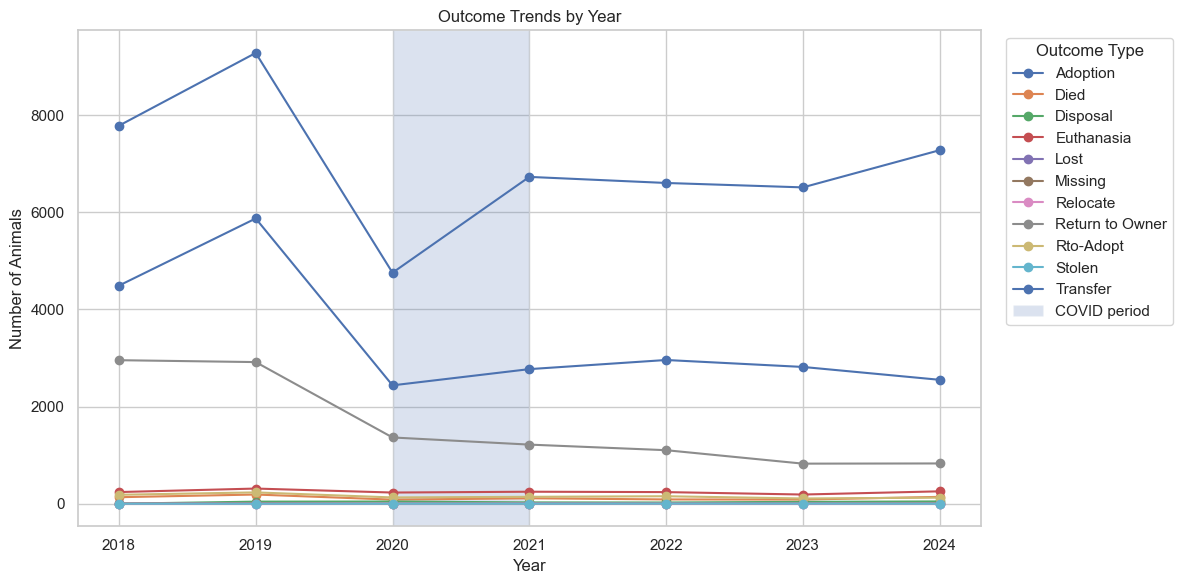

Outcome Type,Adoption,Died,Disposal,Euthanasia,Lost,Missing,Relocate,Return to Owner,Rto-Adopt,Stolen,Transfer
Full Year,,,,,,,,,,,
2018,7783,134,0,240,0,5,0,2955,184,0,4490
2019,9281,189,43,312,0,14,0,2916,233,0,5873
2020,4756,84,45,230,0,1,1,1364,129,0,2437
2021,6729,112,27,247,0,3,3,1217,142,0,2771
2022,6604,88,25,239,0,3,1,1102,154,2,2959
2023,6513,85,38,189,0,9,1,825,108,3,2816
2024,7279,141,47,255,1,7,0,829,125,0,2551


In [20]:
yearly_outcomes = pd.crosstab(df["Full Year"], df["Outcome Type"])

ax = yearly_outcomes.plot(kind="line", marker="o", figsize=(12, 6))
ax.set_title("Outcome Trends by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Animals")
plt.axvspan(2020, 2021, alpha=0.2, label="COVID period")
plt.legend(title="Outcome Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

yearly_outcomes